# VAE - ArtBench

https://www.geeksforgeeks.org/machine-learning/variational-autoencoders/

## Setup

In [18]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

In [19]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [20]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## Dataset

In [21]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = D:\Mestrado\2ºsemestre\IAG\IAG_TP1
SCRIPTS_DIR    = D:\Mestrado\2ºsemestre\IAG\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = D:\Mestrado\2ºsemestre\IAG\IAG_TP1\ArtBench-10
TRAINING CSV   = D:\Mestrado\2ºsemestre\IAG\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [22]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='D:\Mestrado\2ºsemestre\IAG\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [23]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5), # Inverte a pintura lateralmente
    transforms.RandomRotation(degrees=10),  # Roda até 10 graus
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [24]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [25]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [26]:
train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_subset))
print("Número de batches:", len(train_loader))


Tamanho do subset: 10000
Número de batches: 157


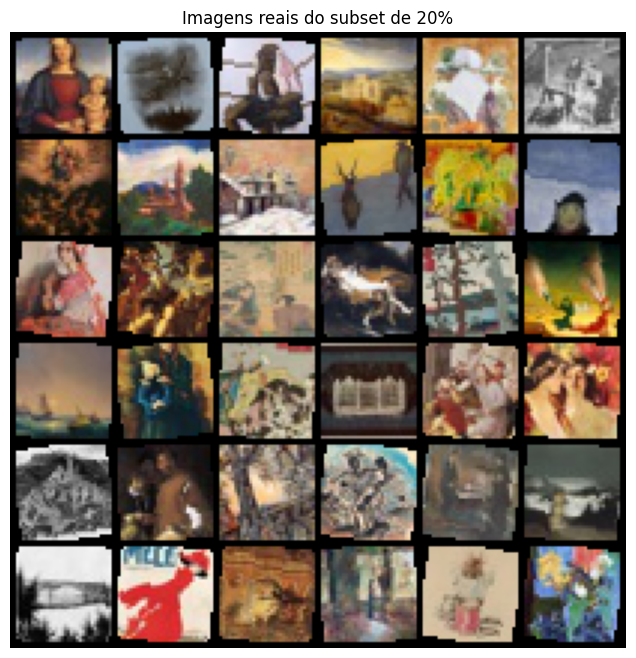

Exemplos de labels:
0: classe=renaissance 
1: classe=romanticism 
2: classe=expressionism 
3: classe=romanticism 
4: classe=post_impressionism 
5: classe=realism 
6: classe=renaissance 
7: classe=post_impressionism 
8: classe=post_impressionism 
9: classe=surrealism 
10: classe=post_impressionism 
11: classe=expressionism 


In [27]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## VAE Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt

# Configurações do Projeto
LATENT_DIM = 256
BETA = 0.001  # Valor sugerido no enunciado para equilibrar nitidez e diversidade
LEARNING_RATE = 1e-3
EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fixar Sementes (Conforme Objetivo 4 do Enunciado)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"A treinar em: {DEVICE}")

A treinar em: cpu


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # ENCODER: Processa 32x32 RGB
        # Seguindo o enunciado: 10 classes de estilos artísticos exigem extração de features complexas
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # -> 8x8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # -> 4x4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        # Vetor Latente (Reparameterization Trick)
        # 128 * 4 * 4 = 2048
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # DECODER: Reconstrói a pintura
        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)
        
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # -> 32x32
            nn.Tanh() # Crucial: ArtBench normalizado para [-1, 1] pede Tanh
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.fc_decode(z)), mu, logvar

    def decode(self, z):
        # Útil para a fase de "Sampling" exigida no enunciado
        return self.decoder(self.fc_decode(z))

In [30]:
def vae_loss_function(recon_x, x, mu, logvar, current_beta):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + (current_beta * kl_loss)
    return total_loss, recon_loss, kl_loss

In [31]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

# 1. Inicializar as métricas (Inception v3 feature layer: 2048)
# O KID é recomendado pelo enunciado por ser mais fiável em subsets pequenos
fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
kid_metric = KernelInceptionDistance(subset_size=50).to(DEVICE)

model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

BETA_FINAL = 0.001
ANNEALING_EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    # Cálculo do Beta Linear (KL Annealing)
    # Se ainda estivermos nas primeiras épocas, o beta cresce. Depois, estabiliza no final.
    current_beta = min(BETA_FINAL, BETA_FINAL * (epoch / ANNEALING_EPOCHS))
    total_loss = 0
    
    for x, r_loss, k_loss in train_loader:
        x = x.to(DEVICE)
        
        # Forward e Backpropagation (Necessário para o modelo aprender)
        recon, mu, logvar = model(x)
        loss, r_loss, k_loss = vae_loss_function(recon, x, mu, logvar, current_beta)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # --- CÁLCULO DE FID E KID (No final de cada 10 épocas ou na última) ---
    if (epoch + 1) % 10 == 0 or (epoch + 1) == EPOCHS:
        model.eval()
        print(f"\\n[Época {epoch+1}] A calcular FID e KID...")
        
        with torch.no_grad():
            for x, _, _ in train_loader:
                # A. Imagens Reais: converter [-1, 1] -> [0, 255] uint8
                real_imgs = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).to(DEVICE)
                fid_metric.update(real_imgs, real=True)
                kid_metric.update(real_imgs, real=True)
                
                # B. Imagens Geradas: amostragem aleatória do espaço latente
                z = torch.randn(x.size(0), LATENT_DIM).to(DEVICE)
                fake_imgs = model.decode(z)
                fake_imgs = ((fake_imgs * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
                
                fid_metric.update(fake_imgs, real=False)
                kid_metric.update(fake_imgs, real=False)
                
                # Para avaliação rápida, paramos após ~1000 imagens
                if fid_metric.real_features_num_samples >= 1000:
                    break

        # Resultados
        current_fid = fid_metric.compute().item()
        current_kid_mean, _ = kid_metric.compute()
        
        print(f">>> FID: {current_fid:.2f} | KID: {current_kid_mean.item():.4f}")
        
        # Reset para a próxima avaliação (opcional, dependendo se queres acumulado)
        fid_metric.reset()
        kid_metric.reset()

    print(f"Época [{epoch+1}/{EPOCHS}] Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'vae_artbench_metrics.pth')

d:\Python311\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Época [1/50] Loss: 0.1632
Época [2/50] Loss: 0.0936
Época [3/50] Loss: 0.0645
Época [4/50] Loss: 0.0537
Época [5/50] Loss: 0.0480
Época [6/50] Loss: 0.0431
Época [7/50] Loss: 0.0410
Época [8/50] Loss: 0.0388
Época [9/50] Loss: 0.0369
\n[Época 10] A calcular FID e KID...
>>> FID: 330.57 | KID: 0.3810
Época [10/50] Loss: 0.0348
Época [11/50] Loss: 0.0342
Época [12/50] Loss: 0.0331
Época [13/50] Loss: 0.0326
Época [14/50] Loss: 0.0316
Época [15/50] Loss: 0.0310
Época [16/50] Loss: 0.0301
Época [17/50] Loss: 0.0290
Época [18/50] Loss: 0.0293
Época [19/50] Loss: 0.0289
\n[Época 20] A calcular FID e KID...
>>> FID: 239.77 | KID: 0.2435
Época [20/50] Loss: 0.0286
Época [21/50] Loss: 0.0287
Época [22/50] Loss: 0.0282
Época [23/50] Loss: 0.0277
Época [24/50] Loss: 0.0277
Época [25/50] Loss: 0.0275
Época [26/50] Loss: 0.0276
Época [27/50] Loss: 0.0275
Época [28/50] Loss: 0.0272
Época [29/50] Loss: 0.0270
\n[Época 30] A calcular FID e KID...
>>> FID: 219.69 | KID: 0.2098
Época [30/50] Loss: 0.026

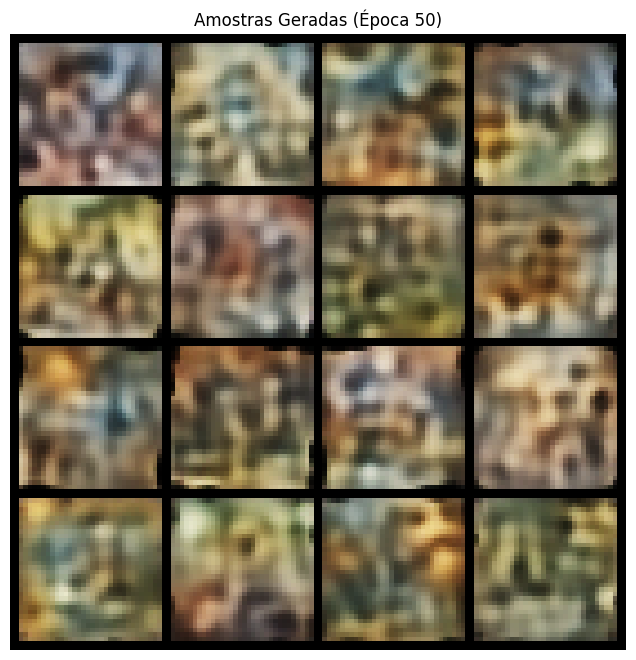

In [32]:
def visualize_vae_results(model, num_samples=16):
    model.eval()
    with torch.no_grad():
        # 1. Gerar do Espaço Latente (Amostragem Aleatória)
        z = torch.randn(num_samples, LATENT_DIM).to(DEVICE)
        samples = model.decode(z)
        
        # Inverter a normalização (-1, 1 -> 0, 1) para o matplotlib
        samples = samples * 0.5 + 0.5
        
        grid = make_grid(samples, nrow=4).permute(1, 2, 0).cpu().numpy()
        
        plt.figure(figsize=(8, 8))
        plt.imshow(grid)
        plt.axis('off')
        plt.title(f"Amostras Geradas (Época {EPOCHS})")
        plt.show()

visualize_vae_results(model)

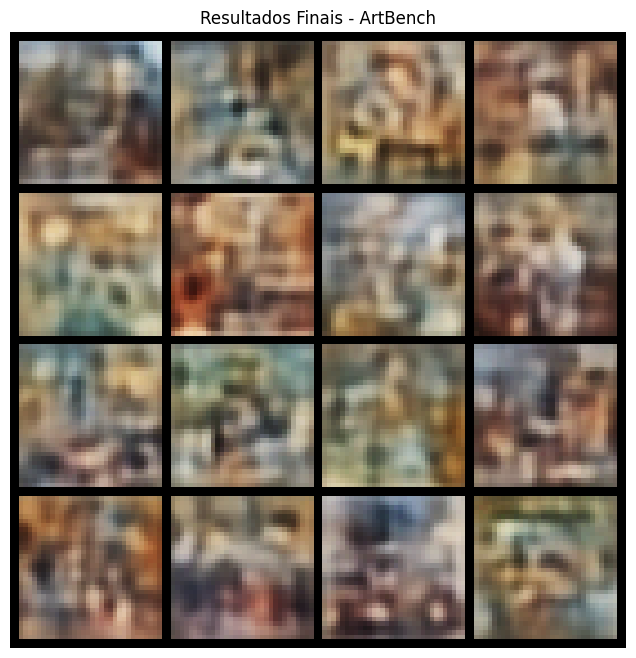

In [17]:
def plot_generated_images(model, device, num_images=16, title="Imagens Geradas pela VAE"):
    model.eval()
    with torch.no_grad():
        # 1. Gerar ruído aleatório no espaço latente
        z = torch.randn(num_images, LATENT_DIM).to(device)
        
        # 2. Passar pelo Decoder
        samples = model.decode(z)
        
        # 3. Desnormalizar: de [-1, 1] para [0, 1]
        samples = samples * 0.5 + 0.5
        samples = samples.clamp(0, 1)
        
        # 4. Criar e mostrar a grelha
        grid = make_grid(samples, nrow=4, padding=2)
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
        plt.title(title)
        plt.show()

# Exemplo de uso:
plot_generated_images(model, DEVICE, title="Resultados Finais - ArtBench")

In [ ]:
import statistics

def evaluate_10_seeds(model, loader, device, num_seeds=10):
    model.eval()
    fids = []
    kids = []
    
    print(f"A iniciar avaliação estatística (10 seeds)...")
    
    for i in range(num_seeds):
        # 1. Mudar a semente em cada iteração
        current_seed = i * 100 # Sementes variadas: 0, 100, 200...
        torch.manual_seed(current_seed)
        
        # Reset das métricas para cada seed
        fid_metric = FrechetInceptionDistance(feature=2048).to(device)
        kid_metric = KernelInceptionDistance(subset_size=50).to(device)
        
        with torch.no_grad():
            for batch_idx, (x, _, _) in enumerate(loader):
                # Imagens Reais
                real = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).to(device)
                fid_metric.update(real, real=True)
                kid_metric.update(real, real=True)
                
                # Imagens Geradas (influenciadas pela seed atual)
                z = torch.randn(x.size(0), LATENT_DIM).to(device)
                fake = model.decode(z)
                fake = ((fake * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8)
                
                fid_metric.update(fake, real=False)
                kid_metric.update(fake, real=False)
                
                # Usar 1000 imagens por seed para ser viável temporalmente
                if fid_metric.real_features_num_samples >= 1000:
                    break
        
        fids.append(fid_metric.compute().item())
        k_mean, _ = kid_metric.compute()
        kids.append(k_mean.item())
        
        print(f"Seed {i+1}/{num_seeds} | FID: {fids[-1]:.2f} | KID: {kids[-1]:.4f}")

    # Cálculos Finais para o Relatório
    print("\n" + "="*30)
    print("RESUMO PARA O RELATÓRIO LATEX")
    print("="*30)
    print(f"FID Médio: {statistics.mean(fids):.2f} ± {statistics.stdev(fids):.2f}")
    print(f"KID Médio: {statistics.mean(kids):.4f} ± {statistics.stdev(kids):.4f}")
    print("="*30)

# Correr a avaliação final
evaluate_10_seeds(model, train_loader, DEVICE)

## Training